# T07: Leakage-Safe Data Preprocessing

## A. Problem and evidence from T01–T06

This notebook implements preprocessing for the validated chronological supervised population. All learned parameters are fitted on Train only; Validation and Test are transform-only. The raw CSV remains immutable.

T03 found strongly station-dependent structural missingness in Sunshine, Evaporation, Cloud9am, and Cloud3pm. T05 found no value with enough evidence to classify as invalid, so extremes remain unchanged. T06 established the whole-date split used here. No feature engineering, class balancing, feature selection, or modelling occurs.

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from fdm_rainfall.data import chronological_train_validation_test_split, load_weather_data
from fdm_rainfall.preprocessing import (
    CATEGORICAL_PREDICTORS,
    MISSING_CATEGORY,
    NUMERICAL_PREDICTORS,
    STRUCTURAL_NUMERICAL_PREDICTORS,
    RainfallPreprocessor,
    predictor_columns,
    separate_supervised_components,
)

DATASET_PATH = PROJECT_ROOT / 'data/raw/weatherAUS.csv'
TABLE_DIR = PROJECT_ROOT / 'reports/tables'
FIGURE_DIR = PROJECT_ROOT / 'reports/figures/preprocessing'
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

raw_hash_before = sha256(DATASET_PATH)
weather = load_weather_data(DATASET_PATH)
split = chronological_train_validation_test_split(weather)
print(f'Raw rows: {len(weather):,}')
print(f'Labelled rows: {sum(len(part) for part in split.frames.values()):,}')
print(f'Excluded missing-target rows: {weather.RainTomorrow.isna().sum():,}')
split.summary

Raw rows: 145,460
Labelled rows: 142,193
Excluded missing-target rows: 3,267


,Split,First date,Last date,Rows,Percentage of labelled rows,Unique dates,Locations,RainTomorrow No count,RainTomorrow Yes count,Yes percentage,Missing target count
0,Train,2007-11-01,2015-01-12,99546,70.007666,2541,49,77087,22459,22.561429,0
1,Validation,2015-01-13,2016-04-08,21342,15.009178,452,48,16990,4352,20.391716,0
2,Test,2016-04-09,2017-06-25,21305,14.983157,443,49,16239,5066,23.778456,0


## Feature roles and target handling

The 16 numerical and five categorical predictors are processed. `RainTomorrow` is separated as y and never enters the transformer. `Date` remains separately aligned for T08 but is neither encoded nor used to derive features here. `RISK_MM` is absent. The 3,267 unlabelled target rows are excluded only from the supervised view; the target is never imputed. Earlier checks found zero exact duplicates and zero duplicate Date–Location keys, so duplicate removal is unnecessary.

In [2]:
components = {
    name: separate_supervised_components(part)
    for name, part in split.frames.items()
}
feature_roles = pd.DataFrame([
    {'Role': 'Numerical predictors', 'Count': len(NUMERICAL_PREDICTORS), 'Columns': ', '.join(NUMERICAL_PREDICTORS)},
    {'Role': 'Categorical predictors', 'Count': len(CATEGORICAL_PREDICTORS), 'Columns': ', '.join(CATEGORICAL_PREDICTORS)},
    {'Role': 'Temporal field kept separately', 'Count': 1, 'Columns': 'Date'},
    {'Role': 'Target kept separately', 'Count': 1, 'Columns': 'RainTomorrow'},
])
assert 'RainTomorrow' not in components['Train'].X
assert 'Date' not in components['Train'].X
assert 'RISK_MM' not in weather.columns
feature_roles

,Role,Count,Columns
0,Numerical predictors,16,"MinTemp, MaxTemp, Rainfall, Evaporation, Sunsh..."
1,Categorical predictors,5,"Location, WindGustDir, WindDir9am, WindDir3pm,..."
2,Temporal field kept separately,1,Date
3,Target kept separately,1,RainTomorrow


## B. Preprocessing decisions

- **Structural numerical missingness:** use a Train-fitted Location median when available, then the global Train median; add four missing indicators. This preserves station structure while providing a deterministic fallback for locations whose Train values are entirely absent.
- **Other numerical missingness:** use robust global Train medians without consulting later subsets.
- **Categorical missingness:** preserve absence as the explicit `Missing` category instead of pretending the modal direction/category was observed.
- **Encoding:** Train-fitted one-hot encoding with unknown categories ignored safely. Raw Date is not encoded and wind directions are not converted to cyclical features.
- **Outliers:** retain all unusual values unchanged; statistical extremeness does not establish a data error. No capping, winsorisation, or row deletion is applied.
- **Scaling:** provide both an unscaled path for future tree methods and a StandardScaler path for future scale-sensitive methods. Only imputed continuous numerics are scaled; the scaler is fitted on Train. No model is used to choose a path.
- **Redundancy:** keep both RainToday and Rainfall. Their strong relationship and the >1.0 mm boundary remain later feature-selection considerations.

## C. Reusable implementation

The reusable `RainfallPreprocessor` owns every fitted parameter. The next cell fits two configurations on Train only. Validation and Test call `transform` without refitting.

In [3]:
unscaled = RainfallPreprocessor(scale_numeric=False).fit(components['Train'].X)
scaled = RainfallPreprocessor(scale_numeric=True).fit(components['Train'].X)

print(f'Original predictors processed: {len(predictor_columns())}')
print(f'Processed output features: {len(unscaled.get_feature_names_out())}')
print(f'Numerical: {len(unscaled.numeric_feature_names_)}; indicators: {len(unscaled.indicator_feature_names_)}; one-hot: {len(unscaled.encoded_feature_names_)}')
print(f'Unscaled fit rows: {unscaled.fit_row_count_:,}; scaled fit rows: {scaled.fit_row_count_:,}')

Original predictors processed: 21
Processed output features: 124
Numerical: 16; indicators: 4; one-hot: 104
Unscaled fit rows: 99,546; scaled fit rows: 99,546


## D. Verification and evidence tables

The following checks compare fitted parameters directly with independent Train calculations, verify row/target alignment, and confirm zero remaining predictor missingness.

In [4]:
prior_missing = pd.read_csv(TABLE_DIR / '03_missing_summary.csv').set_index('Feature')
prior_structural = pd.read_csv(TABLE_DIR / '03_structural_missingness.csv').set_index('Feature')

decision_rows = [
    ('Target', '3,267 missing labels', 'T01/T03/T06 counts', 'Impute; exclude from supervised view', 'Exclude only unlabelled rows in memory; never impute target', 'Supervised learning requires known outcomes', 'No learned parameter', 'Retain raw rows unchanged'),
    ('Duplicates', 'Potential repeated observations', '0 exact and 0 Date + Location duplicates', 'Remove duplicates; retain', 'Retain every labelled row', 'No duplicates require removal', 'No learned parameter', 'Recheck if source changes'),
    ('Sunshine/Evaporation/Cloud9am/Cloud3pm', 'High structural missingness', '38–48% missing; strong station dependence', 'Global median; drop; Location median + fallback', 'Train Location median, then Train global median, plus indicator', 'Preserves features and station structure reproducibly', 'Yes', 'Compare alternatives during modelling without Test'),
    ('Other numerical predictors', 'Low/moderate missingness', 'T03 missingness inventory', 'Mean; median; row deletion', 'Train global median', 'Robust to skew/extremes and retains rows', 'Yes', 'Algorithm-specific alternatives later'),
    ('Categorical predictors', 'Missing wind/RainToday values', 'Missingness is informative source absence', 'Mode; row deletion; explicit category', 'Explicit Missing category', 'Does not invent an observed category', 'Vocabulary from Train plus reserved Missing', 'Review rare categories later'),
    ('Original categorical predictors', 'Non-numeric values and possible unseen categories', 'Five original categorical variables', 'Ordinal; target; one-hot encoding', 'Train-fitted one-hot, handle unknown safely', 'Conventional and leakage-safe', 'Yes', 'Cyclical wind belongs to T08'),
    ('Extreme/suspicious values', 'Long tails and unresolved source values', 'T05 found no likely-invalid values', 'Delete; cap; winsorise; retain', 'Retain unchanged', 'Statistical outlier is not confirmed error', 'No learned treatment', 'Alternative treatment remains experiment'),
    ('Numerical scale', 'Algorithms differ in scale sensitivity', 'Mixed units and long-tailed weather measures', 'No scaling; standard; robust scaling', 'Configurable unscaled and Train-fitted StandardScaler paths', 'Supports future algorithm families without model choice now', 'Yes for scaled path', 'Choose path during modelling'),
    ('Date', 'Needed for chronology and later temporal features', 'T06 split field', 'One-hot raw string; derive features now; preserve separately', 'Preserve separately, exclude from transformer', 'Avoids raw-date encoding and defers T08', 'No', 'Date-derived features in T08'),
    ('RainToday and Rainfall', 'High redundancy and threshold boundary', 'T04: dataset convention Rainfall > 1.0 mm', 'Drop one now; retain both', 'Retain both', 'No model-based feature selection in T07', 'No', 'Feature-selection consideration later'),
]
decisions = pd.DataFrame(decision_rows, columns=['Feature / Feature group','Issue','Evidence','Options considered','Chosen preprocessing','Why chosen','Train-only fitted?','Future consideration'])

numeric_rows = []
for feature in NUMERICAL_PREDICTORS:
    structural = feature in STRUCTURAL_NUMERICAL_PREDICTORS
    numeric_rows.append({
        'Feature': feature,
        'Raw missing %': float(prior_missing.loc[feature, 'Missing percentage']),
        'Train missing %': round(components['Train'].X[feature].isna().mean() * 100, 6),
        'Missingness pattern': prior_structural.loc[feature, 'Provisional pattern'] if feature in prior_structural.index else prior_missing.loc[feature, 'Descriptive severity'],
        'Chosen strategy': 'Train Location median, then Train global median' if structural else 'Train global median',
        'Statistic/grouping used': 'Location and global Train medians' if structural else 'Global Train median',
        'Train-only fitted?': True,
        'Missing indicator added?': structural,
        'Reason': 'Station-dependent structural missingness' if structural else 'Robust central value without row deletion',
    })
numeric_strategy = pd.DataFrame(numeric_rows)

structural_parts = []
for split_name, part in components.items():
    summary = unscaled.structural_imputation_sources(part.X)
    summary.insert(0, 'Split', split_name)
    structural_parts.append(summary)
structural_summary = pd.concat(structural_parts, ignore_index=True)

unknown_validation = unscaled.unknown_category_counts(components['Validation'].X)
unknown_test = unscaled.unknown_category_counts(components['Test'].X)
categorical_rows = []
for position, feature in enumerate(CATEGORICAL_PREDICTORS):
    categories = list(unscaled.categorical_categories_[position])
    categorical_rows.append({
        'Feature': feature,
        'Train missing rows': int(components['Train'].X[feature].isna().sum()),
        'Missing-value treatment': 'Explicit Missing category',
        'Encoder': 'Train-fitted OneHotEncoder(handle_unknown=ignore)',
        'Train vocabulary including reserved Missing': ' | '.join(categories),
        'Encoded columns': len(categories),
        'Validation unknown rows': int(unknown_validation[feature]),
        'Test unknown rows': int(unknown_test[feature]),
        'Train-only fitted?': True,
    })
categorical_summary = pd.DataFrame(categorical_rows)
encoding_summary = categorical_summary[['Feature','Encoded columns','Validation unknown rows','Test unknown rows']].copy()

missing_rows = []
row_alignment_pass = True
for split_name, part in components.items():
    unscaled_output = unscaled.transform(part.X)
    scaled_output = scaled.transform(part.X)
    row_alignment_pass = row_alignment_pass and unscaled_output.index.equals(part.y.index) and scaled_output.index.equals(part.y.index)
    missing_rows.append({
        'Split': split_name,
        'Rows before': len(part.X),
        'Rows after': len(unscaled_output),
        'Predictor missing cells before': int(part.X.isna().sum().sum()),
        'Numerical missing cells before': int(part.X[list(NUMERICAL_PREDICTORS)].isna().sum().sum()),
        'Categorical missing cells before': int(part.X[list(CATEGORICAL_PREDICTORS)].isna().sum().sum()),
        'Unscaled missing cells after': int(unscaled_output.isna().sum().sum()),
        'Scaled missing cells after': int(scaled_output.isna().sum().sum()),
        'Target rows aligned': unscaled_output.index.equals(part.y.index),
    })
missing_before_after = pd.DataFrame(missing_rows)

imputed_train, _ = scaled.impute_numeric(components['Train'].X)
scaling_summary = pd.DataFrame({
    'Feature': NUMERICAL_PREDICTORS,
    'Train-fitted mean': scaled.scaler_.mean_,
    'Train-fitted scale': scaled.scaler_.scale_,
    'Fit rows': scaled.fit_row_count_,
    'Validation/Test used in fit?': False,
    'Scaled path': 'StandardScaler',
    'Unscaled path available?': True,
})

schema_rows = []
for name in unscaled.get_feature_names_out():
    if name in NUMERICAL_PREDICTORS:
        role, scaled_in_path = 'Imputed numerical predictor', True
    elif name in unscaled.indicator_feature_names_:
        role, scaled_in_path = 'Structural missingness indicator', False
    else:
        role, scaled_in_path = 'One-hot encoded original category', False
    schema_rows.append({'Processed feature': name, 'Role': role, 'Present in unscaled path': True, 'Present in scaled path': True, 'Scaled in scaled path': scaled_in_path})
processed_schema = pd.DataFrame(schema_rows)

location_medians_match = all(
    unscaled.structural_location_medians_[feature].equals(components['Train'].X.groupby('Location', dropna=False)[feature].median())
    for feature in STRUCTURAL_NUMERICAL_PREDICTORS
)
category_vocab_match = all(
    set(unscaled.categorical_categories_[position]) == set(components['Train'].X[feature].fillna(MISSING_CATEGORY).astype(str)) | {MISSING_CATEGORY}
    for position, feature in enumerate(CATEGORICAL_PREDICTORS)
)
leakage_checks = pd.DataFrame([
    ('RainTomorrow excluded from X', 'RainTomorrow' not in components['Train'].X, 'Target separated before fit'),
    ('Date excluded from transformer', 'Date' not in components['Train'].X, 'Date retained separately for T08'),
    ('RISK_MM absent', 'RISK_MM' not in weather.columns, 'Checked in raw data and preprocessing API'),
    ('Numerical medians equal Train calculations', unscaled.numeric_medians_.equals(components['Train'].X[list(NUMERICAL_PREDICTORS)].median()), 'No Validation/Test statistics'),
    ('Location medians equal Train calculations', location_medians_match, 'Four structural features grouped on Train'),
    ('Categorical vocabulary equals Train plus reserved Missing', category_vocab_match, 'Encoder fit on Train only'),
    ('Scaler mean equals imputed Train mean', np.allclose(scaled.scaler_.mean_, imputed_train[list(NUMERICAL_PREDICTORS)].mean().to_numpy()), 'Scaler fit on Train only'),
    ('Both preprocessors fitted on 99,546 Train rows', unscaled.fit_row_count_ == scaled.fit_row_count_ == 99546, 'Validation/Test transform-only'),
    ('Rows preserved and targets aligned', row_alignment_pass and (missing_before_after['Rows before'] == missing_before_after['Rows after']).all(), 'No predictor-row deletion'),
    ('No missing processed predictors', (missing_before_after[['Unscaled missing cells after','Scaled missing cells after']] == 0).all().all(), 'All split/path combinations checked'),
    ('T06 split boundaries unchanged', split.summary['Last date'].tolist()[:2] == ['2015-01-12','2016-04-08'], 'Existing chronological splitter reused'),
    ('Unknown categories handled safely', unknown_validation.sum() == 0 and unknown_test.sum() == 0, 'Observed later unknowns are zero; API test injects unseen values'),
    ('No feature engineering', len(unscaled.indicator_feature_names_) == 4 and not any(name in unscaled.get_feature_names_out() for name in ['Year','Month','Season','DayOfYear']), 'Only requested missing indicators and one-hot expansion'),
], columns=['Check','Passed','Evidence'])
leakage_checks['Result'] = np.where(leakage_checks['Passed'], 'PASS', 'FAIL')

decisions.to_csv(TABLE_DIR / '07_preprocessing_decisions.csv', index=False)
numeric_strategy.to_csv(TABLE_DIR / '07_numeric_imputation_strategy.csv', index=False)
structural_summary.to_csv(TABLE_DIR / '07_structural_imputation_summary.csv', index=False)
categorical_summary.to_csv(TABLE_DIR / '07_categorical_preprocessing_summary.csv', index=False)
missing_before_after.to_csv(TABLE_DIR / '07_missing_before_after.csv', index=False)
encoding_summary.to_csv(TABLE_DIR / '07_encoding_summary.csv', index=False)
scaling_summary.to_csv(TABLE_DIR / '07_scaling_summary.csv', index=False)
leakage_checks.to_csv(TABLE_DIR / '07_leakage_preprocessing_checks.csv', index=False)
processed_schema.to_csv(TABLE_DIR / '07_processed_schema_summary.csv', index=False)

assert leakage_checks['Passed'].all()
print(leakage_checks[['Check','Result']].to_string(index=False))
missing_before_after

                                                    Check Result
                             RainTomorrow excluded from X   PASS
                           Date excluded from transformer   PASS
                                           RISK_MM absent   PASS
               Numerical medians equal Train calculations   PASS
                Location medians equal Train calculations   PASS
Categorical vocabulary equals Train plus reserved Missing   PASS
                    Scaler mean equals imputed Train mean   PASS
           Both preprocessors fitted on 99,546 Train rows   PASS
                       Rows preserved and targets aligned   PASS
                          No missing processed predictors   PASS
                           T06 split boundaries unchanged   PASS
                        Unknown categories handled safely   PASS
                                   No feature engineering   PASS


,Split,Rows before,Rows after,Predictor missing cells before,Numerical missing cells before,Categorical missing cells before,Unscaled missing cells after,Scaled missing cells after,Target rows aligned
0,Train,99546,99546,202214,184857,17357,0,0,True
1,Validation,21342,21342,51352,47946,3406,0,0,True
2,Test,21305,21305,62993,59229,3764,0,0,True


## Evidence-focused figures

The first figure verifies elimination of predictor missingness without row deletion. The second shows how the structural strategy divides missing values between station-specific Train medians and the Train-global fallback.

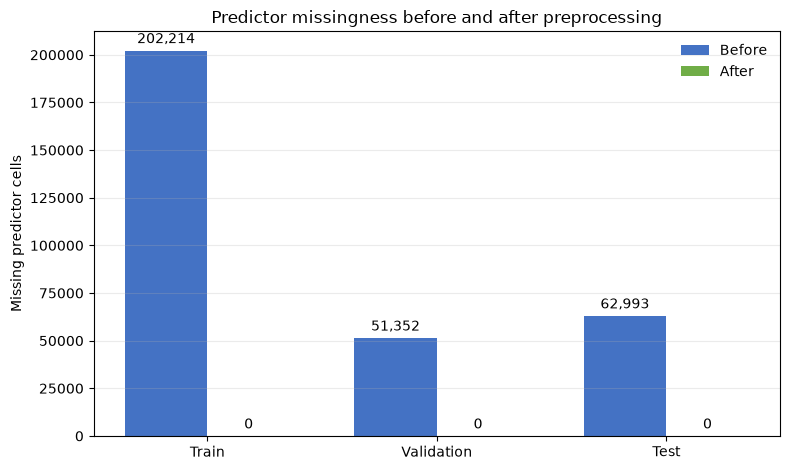

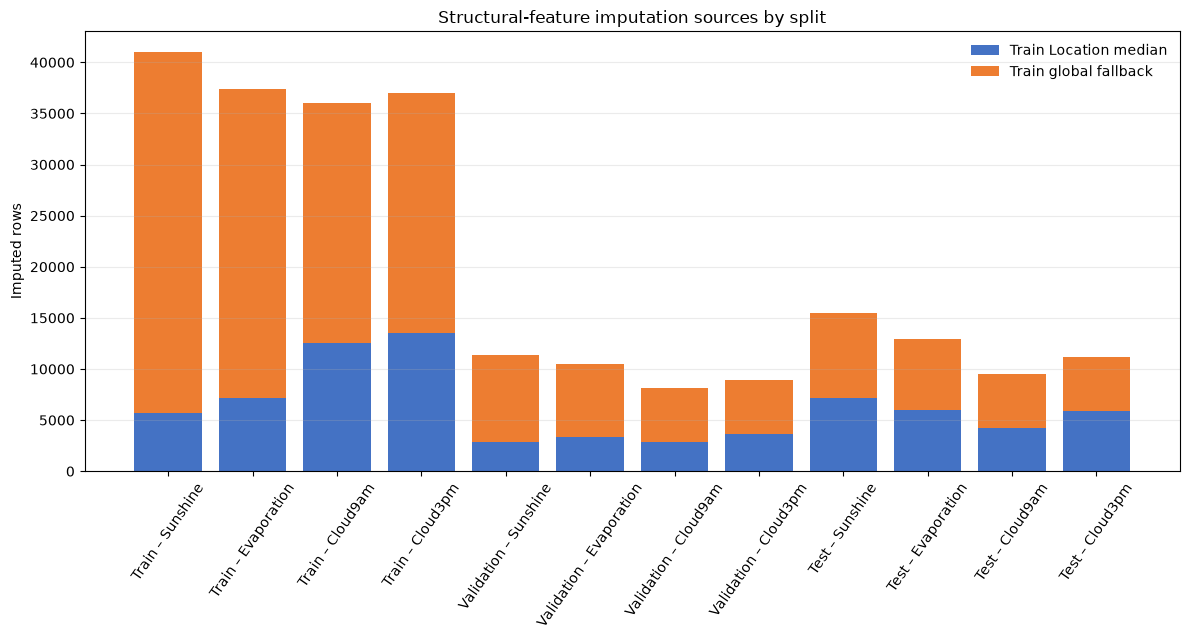

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.8))
x = np.arange(len(missing_before_after))
width = 0.36
before_bars = ax.bar(x - width/2, missing_before_after['Predictor missing cells before'], width, label='Before', color='#4472C4')
after_bars = ax.bar(x + width/2, missing_before_after['Unscaled missing cells after'], width, label='After', color='#70AD47')
ax.bar_label(before_bars, fmt='{:,.0f}', padding=3)
ax.bar_label(after_bars, fmt='{:,.0f}', padding=3)
ax.set_xticks(x, missing_before_after['Split'])
ax.set_ylabel('Missing predictor cells')
ax.set_title('Predictor missingness before and after preprocessing')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '07_missingness_before_after.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

source_plot = structural_summary.copy()
source_plot['Label'] = source_plot['Split'] + ' – ' + source_plot['Feature']
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(source_plot['Label'], source_plot['Location-median imputations'], label='Train Location median', color='#4472C4')
ax.bar(source_plot['Label'], source_plot['Global-fallback imputations'], bottom=source_plot['Location-median imputations'], label='Train global fallback', color='#ED7D31')
ax.set_ylabel('Imputed rows')
ax.set_title('Structural-feature imputation sources by split')
ax.tick_params(axis='x', rotation=55)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '07_structural_imputation_sources.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

## E. Limitations and future considerations

Location medians preserve broad station context but do not model time-varying measurement practices. Global fallback is necessarily used where a station has no observed Train values. Missing indicators allow later algorithms to recognise structural absence, but their usefulness must be evaluated without using Test for selection. Standard scaling is only one future algorithm-compatible path and is not claimed to improve performance.

Deferred to T08: all Date-derived variables, cyclical wind representations, weather-difference features, and other engineered predictors. Deferred to modelling: algorithm-specific path choice, model-based feature selection, class balancing, hyperparameter tuning, and probability-threshold decisions.

In [6]:
raw_hash_after = sha256(DATASET_PATH)
assert raw_hash_after == raw_hash_before
assert len(processed_schema) == 124
assert len(unscaled.encoded_feature_names_) == 104
assert (missing_before_after['Rows before'] == [99546, 21342, 21305]).all()
assert (missing_before_after[['Unscaled missing cells after','Scaled missing cells after']] == 0).all().all()
print(f'Raw SHA-256 unchanged: {raw_hash_after}')
print('Processed features: 124 = 16 numerical + 4 missing indicators + 104 one-hot columns')
print('T07 complete within scope: no feature engineering, balancing, feature selection, or model training.')

Raw SHA-256 unchanged: 573fd715cd69fcacc4df32024d823b450ae3edaae7e8ff2eeb623adbed424014
Processed features: 124 = 16 numerical + 4 missing indicators + 104 one-hot columns
T07 complete within scope: no feature engineering, balancing, feature selection, or model training.
